In [2]:
import sqlite3
import pandas as pd
import os

DATA_DIR = "/content/data"
DB_PATH = "olist.db"
if os.path.exists(DB_PATH):
    os.remove(DB_PATH)

conn = sqlite3.connect(DB_PATH)
cursor = conn.cursor()

# ── Create Tables with Schema ──
cursor.executescript("""
CREATE TABLE customers (
    customer_id TEXT PRIMARY KEY,
    customer_unique_id TEXT NOT NULL,
    customer_zip_code_prefix TEXT,
    customer_city TEXT,
    customer_state TEXT
);

CREATE TABLE sellers (
    seller_id TEXT PRIMARY KEY,
    seller_zip_code_prefix TEXT,
    seller_city TEXT,
    seller_state TEXT
);

CREATE TABLE products (
    product_id TEXT PRIMARY KEY,
    product_category_name TEXT,
    product_name_lenght REAL,
    product_description_lenght REAL,
    product_photos_qty REAL,
    product_weight_g REAL,
    product_length_cm REAL,
    product_height_cm REAL,
    product_width_cm REAL
);

CREATE TABLE category_translation (
    product_category_name TEXT PRIMARY KEY,
    product_category_name_english TEXT
);

CREATE TABLE orders (
    order_id TEXT PRIMARY KEY,
    customer_id TEXT NOT NULL,
    order_status TEXT,
    order_purchase_timestamp TEXT,
    order_approved_at TEXT,
    order_delivered_carrier_date TEXT,
    order_delivered_customer_date TEXT,
    order_estimated_delivery_date TEXT,
    FOREIGN KEY (customer_id) REFERENCES customers(customer_id)
);

CREATE TABLE order_items (
    order_id TEXT NOT NULL,
    order_item_id INTEGER NOT NULL,
    product_id TEXT NOT NULL,
    seller_id TEXT NOT NULL,
    shipping_limit_date TEXT,
    price REAL,
    freight_value REAL,
    PRIMARY KEY (order_id, order_item_id),
    FOREIGN KEY (order_id) REFERENCES orders(order_id),
    FOREIGN KEY (product_id) REFERENCES products(product_id),
    FOREIGN KEY (seller_id) REFERENCES sellers(seller_id)
);

CREATE TABLE order_payments (
    order_id TEXT NOT NULL,
    payment_sequential INTEGER,
    payment_type TEXT,
    payment_installments INTEGER,
    payment_value REAL,
    FOREIGN KEY (order_id) REFERENCES orders(order_id)
);

CREATE TABLE order_reviews (
    review_id TEXT,
    order_id TEXT NOT NULL,
    review_score INTEGER,
    review_comment_title TEXT,
    review_comment_message TEXT,
    review_creation_date TEXT,
    review_answer_timestamp TEXT,
    FOREIGN KEY (order_id) REFERENCES orders(order_id)
);
""")

# ── Load CSVs ──
table_file_map = {
    "customers":            "olist_customers_dataset.csv",
    "sellers":              "olist_sellers_dataset.csv",
    "products":             "olist_products_dataset.csv",
    "category_translation": "product_category_name_translation.csv",
    "orders":               "olist_orders_dataset.csv",
    "order_items":          "olist_order_items_dataset.csv",
    "order_payments":       "olist_order_payments_dataset.csv",
    "order_reviews":        "olist_order_reviews_dataset.csv",
}

for table_name, csv_file in table_file_map.items():
    filepath = os.path.join(DATA_DIR, csv_file)
    df = pd.read_csv(filepath)
    df.to_sql(table_name, conn, if_exists="append", index=False)
    print(f"  {table_name:25s}: {len(df):>10,} rows loaded")

# ── Create Indexes ──
cursor.executescript("""
CREATE INDEX idx_orders_customer ON orders(customer_id);
CREATE INDEX idx_orders_purchase ON orders(order_purchase_timestamp);
CREATE INDEX idx_order_items_order ON order_items(order_id);
CREATE INDEX idx_order_items_product ON order_items(product_id);
CREATE INDEX idx_order_items_seller ON order_items(seller_id);
CREATE INDEX idx_payments_order ON order_payments(order_id);
CREATE INDEX idx_reviews_order ON order_reviews(order_id);
""")
conn.commit()

print("\n Database created successfully!")

  customers                :     99,441 rows loaded
  sellers                  :      3,095 rows loaded
  products                 :     32,951 rows loaded
  category_translation     :         71 rows loaded
  orders                   :     99,441 rows loaded
  order_items              :    112,650 rows loaded
  order_payments           :    103,886 rows loaded
  order_reviews            :     99,224 rows loaded

 Database created successfully!


## SQL Analysis — 12 Queries

In [3]:
def sql(query, conn=conn):
    """Run SQL query and return formatted DataFrame."""
    return pd.read_sql_query(query, conn)

### Q1. Monthly Revenue Trend

In [4]:
sql("""
SELECT
    STRFTIME('%Y-%m', o.order_purchase_timestamp) AS order_month,
    COUNT(DISTINCT o.order_id) AS total_orders,
    COUNT(DISTINCT o.customer_id) AS unique_customers,
    ROUND(SUM(oi.price + oi.freight_value), 2) AS total_revenue,
    ROUND(AVG(oi.price + oi.freight_value), 2) AS avg_order_value
FROM orders o
JOIN order_items oi ON o.order_id = oi.order_id
WHERE o.order_status = 'delivered'
  AND o.order_purchase_timestamp >= '2017-01-01'
GROUP BY order_month
ORDER BY order_month;
""")

,order_month,total_orders,unique_customers,total_revenue,avg_order_value
0,2017-01,750,750,127482.37,139.63
1,2017-02,1653,1653,271239.32,145.98
2,2017-03,2546,2546,414330.95,143.02
3,2017-04,2303,2303,390812.40,152.13
4,2017-05,3546,3546,566851.40,141.57
5,2017-06,3135,3135,490050.37,140.46
6,2017-07,3872,3872,566299.08,128.24
7,2017-08,4193,4193,645832.36,134.63
8,2017-09,4150,4150,701077.49,148.00
9,2017-10,4478,4478,751117.01,144.06


### Q2. Top 15 Product Categories by Revenue

In [5]:
sql("""
SELECT
    COALESCE(ct.product_category_name_english, p.product_category_name, 'Unknown')
        AS category,
    COUNT(DISTINCT oi.order_id) AS order_count,
    ROUND(SUM(oi.price), 2) AS product_revenue,
    ROUND(SUM(oi.freight_value), 2) AS freight_revenue,
    ROUND(SUM(oi.price + oi.freight_value), 2) AS total_revenue,
    ROUND(AVG(oi.price), 2) AS avg_price
FROM order_items oi
JOIN products p ON oi.product_id = p.product_id
LEFT JOIN category_translation ct ON p.product_category_name = ct.product_category_name
JOIN orders o ON oi.order_id = o.order_id
WHERE o.order_status = 'delivered'
GROUP BY category
ORDER BY total_revenue DESC
LIMIT 15;
""")

,category,order_count,product_revenue,freight_revenue,total_revenue,avg_price
0,health_beauty,8647,1233131.72,178957.81,1412089.53,130.28
1,watches_gifts,5495,1166176.98,98156.14,1264333.12,199.04
2,bed_bath_table,9272,1023434.76,201774.50,1225209.26,93.44
3,sports_leisure,7530,954852.55,163404.36,1118256.91,113.25
4,computers_accessories,6530,888724.61,143999.16,1032723.77,116.26
5,furniture_decor,6307,711927.69,168402.23,880329.92,87.25
6,housewares,5743,615628.69,142763.56,758392.25,90.60
7,cool_stuff,3559,610204.10,81476.79,691680.89,164.12
8,auto,3810,578966.65,90488.10,669454.75,139.85
9,garden_tools,3448,470495.28,96650.40,567145.68,110.24


### Q3. Month-over-Month Revenue Growth

In [6]:
sql("""
WITH monthly AS (
    SELECT
        STRFTIME('%Y-%m', o.order_purchase_timestamp) AS month,
        ROUND(SUM(oi.price + oi.freight_value), 2) AS revenue,
        COUNT(DISTINCT o.order_id) AS orders
    FROM orders o
    JOIN order_items oi ON o.order_id = oi.order_id
    WHERE o.order_status = 'delivered'
      AND o.order_purchase_timestamp >= '2017-01-01'
    GROUP BY month
)
SELECT
    month,
    revenue,
    orders,
    LAG(revenue) OVER (ORDER BY month) AS prev_revenue,
    ROUND(100.0 * (revenue - LAG(revenue) OVER (ORDER BY month))
          / LAG(revenue) OVER (ORDER BY month), 1) AS revenue_growth_pct,
    LAG(orders) OVER (ORDER BY month) AS prev_orders,
    ROUND(100.0 * (orders - LAG(orders) OVER (ORDER BY month))
          / LAG(orders) OVER (ORDER BY month), 1) AS order_growth_pct
FROM monthly
ORDER BY month;
""")

,month,revenue,orders,prev_revenue,revenue_growth_pct,prev_orders,order_growth_pct
0,2017-01,127482.37,750,NaN,NaN,NaN,NaN
1,2017-02,271239.32,1653,127482.37,112.8,750.0,120.4
2,2017-03,414330.95,2546,271239.32,52.8,1653.0,54.0
3,2017-04,390812.40,2303,414330.95,-5.7,2546.0,-9.5
4,2017-05,566851.40,3546,390812.40,45.0,2303.0,54.0
5,2017-06,490050.37,3135,566851.40,-13.5,3546.0,-11.6
6,2017-07,566299.08,3872,490050.37,15.6,3135.0,23.5
7,2017-08,645832.36,4193,566299.08,14.0,3872.0,8.3
8,2017-09,701077.49,4150,645832.36,8.6,4193.0,-1.0
9,2017-10,751117.01,4478,701077.49,7.1,4150.0,7.9


### Q4. Seller Performance Ranking

In [7]:
sql("""
WITH seller_stats AS (
    SELECT
        s.seller_id,
        s.seller_city,
        s.seller_state,
        COUNT(DISTINCT oi.order_id) AS total_orders,
        ROUND(SUM(oi.price), 2) AS total_revenue,
        ROUND(AVG(r.review_score), 2) AS avg_review_score
    FROM sellers s
    JOIN order_items oi ON s.seller_id = oi.seller_id
    JOIN orders o ON oi.order_id = o.order_id
    LEFT JOIN order_reviews r ON o.order_id = r.order_id
    WHERE o.order_status = 'delivered'
    GROUP BY s.seller_id, s.seller_city, s.seller_state
    HAVING COUNT(DISTINCT oi.order_id) >= 20
)
SELECT
    seller_city,
    seller_state,
    total_orders,
    total_revenue,
    avg_review_score,
    RANK() OVER (ORDER BY total_revenue DESC) AS overall_rank,
    RANK() OVER (PARTITION BY seller_state ORDER BY total_revenue DESC) AS state_rank
FROM seller_stats
ORDER BY total_revenue DESC
LIMIT 20;
""")

,seller_city,seller_state,total_orders,total_revenue,avg_review_score,overall_rank,state_rank
0,guariba,SP,1124,226987.93,4.14,1,1
1,lauro de freitas,BA,348,217940.44,4.13,2,1
2,ibitinga,SP,1772,199408.32,3.83,3,2
3,sumare,SP,578,190917.14,4.37,4,3
4,itaquaquecetuba,SP,973,188063.83,3.35,5,4
5,barueri,SP,319,165981.49,4.36,6,5
6,piracicaba,SP,1311,162303.67,4.08,7,6
7,sao paulo,SP,1145,140238.65,4.27,8,7
8,sao paulo,SP,910,139720.16,3.87,9,8
9,sao paulo,SP,1261,131906.71,4.09,10,9


### Q5. Delivery Performance by State

In [8]:
sql("""
SELECT
    c.customer_state,
    COUNT(*) AS total_orders,
    ROUND(AVG(
        JULIANDAY(o.order_delivered_customer_date) - JULIANDAY(o.order_purchase_timestamp)
    ), 1) AS avg_delivery_days,
    ROUND(AVG(
        JULIANDAY(o.order_estimated_delivery_date) - JULIANDAY(o.order_purchase_timestamp)
    ), 1) AS avg_estimated_days,
    ROUND(100.0 * SUM(CASE
        WHEN o.order_delivered_customer_date <= o.order_estimated_delivery_date THEN 1
        ELSE 0
    END) / COUNT(*), 1) AS on_time_pct,
    ROUND(AVG(
        JULIANDAY(o.order_delivered_customer_date) - JULIANDAY(o.order_estimated_delivery_date)
    ), 1) AS avg_delay_days
FROM orders o
JOIN customers c ON o.customer_id = c.customer_id
WHERE o.order_status = 'delivered'
  AND o.order_delivered_customer_date IS NOT NULL
GROUP BY c.customer_state
HAVING COUNT(*) >= 100
ORDER BY on_time_pct DESC;
""")

,customer_state,total_orders,avg_delivery_days,avg_estimated_days,on_time_pct,avg_delay_days
0,RO,243,19.4,38.8,97.1,-19.4
1,AM,145,26.4,45.3,95.9,-18.9
2,PR,4923,12.0,24.6,95.0,-12.6
3,MG,11354,12.0,24.5,94.4,-12.5
4,SP,40494,8.8,19.1,94.1,-10.4
5,MT,886,18.1,31.7,93.2,-13.7
6,RS,5344,15.3,28.5,92.9,-13.2
7,DF,2080,13.0,24.3,92.9,-11.3
8,GO,1957,15.6,27.1,91.8,-11.5
9,SC,3546,15.0,25.8,90.2,-10.8


### Q6. Payment Method Analysis

In [9]:
sql("""
WITH order_totals AS (
    SELECT
        op.order_id,
        op.payment_type,
        SUM(op.payment_value) AS total_paid,
        MAX(op.payment_installments) AS max_installments
    FROM order_payments op
    GROUP BY op.order_id, op.payment_type
)
SELECT
    payment_type,
    COUNT(*) AS transaction_count,
    ROUND(SUM(total_paid), 2) AS total_revenue,
    ROUND(AVG(total_paid), 2) AS avg_payment,
    ROUND(AVG(max_installments), 1) AS avg_installments,
    SUM(CASE WHEN total_paid < 50 THEN 1 ELSE 0 END) AS under_50,
    SUM(CASE WHEN total_paid BETWEEN 50 AND 200 THEN 1 ELSE 0 END) AS between_50_200,
    SUM(CASE WHEN total_paid BETWEEN 200 AND 500 THEN 1 ELSE 0 END) AS between_200_500,
    SUM(CASE WHEN total_paid > 500 THEN 1 ELSE 0 END) AS over_500
FROM order_totals
GROUP BY payment_type
ORDER BY total_revenue DESC;
""")

,payment_type,transaction_count,total_revenue,avg_payment,avg_installments,under_50,between_50_200,between_200_500,over_500
0,credit_card,76505,12542084.19,163.94,3.5,13164,47104,12747,3491
1,boleto,19784,2869361.27,145.03,1.0,4043,12401,2662,678
2,voucher,3866,379436.87,98.15,1.0,1316,2231,270,63
3,debit_card,1528,217989.79,142.66,1.0,368,918,198,44
4,not_defined,3,0.00,0.00,1.0,3,0,0,0


### Q7. Review Score vs Delivery Speed

In [10]:
sql("""
SELECT
    r.review_score,
    COUNT(*) AS review_count,
    ROUND(AVG(sub.delivery_days), 1) AS avg_delivery_days,
    ROUND(AVG(sub.delay_days), 1) AS avg_delay_days,
    ROUND(AVG(sub.price), 2) AS avg_order_value,
    ROUND(100.0 * SUM(CASE WHEN sub.delay_days > 0 THEN 1 ELSE 0 END)
          / COUNT(*), 1) AS late_delivery_pct
FROM order_reviews r
JOIN (
    SELECT
        o.order_id,
        JULIANDAY(o.order_delivered_customer_date) - JULIANDAY(o.order_purchase_timestamp)
            AS delivery_days,
        JULIANDAY(o.order_delivered_customer_date) - JULIANDAY(o.order_estimated_delivery_date)
            AS delay_days,
        SUM(oi.price) AS price
    FROM orders o
    JOIN order_items oi ON o.order_id = oi.order_id
    WHERE o.order_status = 'delivered'
      AND o.order_delivered_customer_date IS NOT NULL
    GROUP BY o.order_id
) sub ON r.order_id = sub.order_id
GROUP BY r.review_score
ORDER BY r.review_score;
""")

,review_score,review_count,avg_delivery_days,avg_delay_days,avg_order_value,late_delivery_pct
0,1,9405,21.3,-3.4,164.91,37.8
1,2,2941,16.7,-7.9,143.66,20.6
2,3,7961,14.3,-10.1,127.48,11.0
3,4,18987,12.3,-11.7,132.11,5.0
4,5,57059,10.7,-12.7,134.43,3.0


### Q8. RFM Customer Segmentatio

In [11]:
sql("""
WITH customer_rfm AS (
    SELECT
        c.customer_unique_id,
        MAX(o.order_purchase_timestamp) AS last_purchase,
        CAST(JULIANDAY('2018-09-01') - JULIANDAY(MAX(o.order_purchase_timestamp)) AS INTEGER)
            AS recency_days,
        COUNT(DISTINCT o.order_id) AS frequency,
        ROUND(SUM(oi.price + oi.freight_value), 2) AS monetary
    FROM customers c
    JOIN orders o ON c.customer_id = o.customer_id
    JOIN order_items oi ON o.order_id = oi.order_id
    WHERE o.order_status = 'delivered'
    GROUP BY c.customer_unique_id
),
rfm_scores AS (
    SELECT *,
        NTILE(4) OVER (ORDER BY recency_days DESC) AS r_score,
        NTILE(4) OVER (ORDER BY frequency ASC) AS f_score,
        NTILE(4) OVER (ORDER BY monetary ASC) AS m_score
    FROM customer_rfm
)
SELECT
    CASE
        WHEN r_score >= 3 AND f_score >= 3 AND m_score >= 3 THEN 'Champions'
        WHEN r_score >= 3 AND f_score >= 2 THEN 'Loyal Customers'
        WHEN r_score >= 3 THEN 'Recent Customers'
        WHEN r_score >= 2 AND f_score >= 2 THEN 'At Risk'
        WHEN f_score >= 3 THEN 'Cant Lose Them'
        ELSE 'Lost'
    END AS segment,
    COUNT(*) AS customer_count,
    ROUND(AVG(recency_days), 0) AS avg_recency,
    ROUND(AVG(frequency), 1) AS avg_frequency,
    ROUND(AVG(monetary), 2) AS avg_monetary,
    ROUND(SUM(monetary), 2) AS total_revenue
FROM rfm_scores
GROUP BY segment
ORDER BY total_revenue DESC;
""")

,segment,customer_count,avg_recency,avg_frequency,avg_monetary,total_revenue
0,Champions,23677,113.0,1.1,267.08,6323591.65
1,At Risk,17596,279.0,1.0,202.24,3558555.43
2,Cant Lose Them,11258,454.0,1.1,271.28,3054118.77
3,Lost,17826,396.0,1.0,57.41,1023381.09
4,Loyal Customers,11395,113.0,1.0,83.89,955927.25
5,Recent Customers,11606,114.0,1.0,43.44,504199.56


### Q9. Cumulative Revenue Share — Pareto / 80-20 Analysis

In [12]:
sql("""
WITH category_rev AS (
    SELECT
        COALESCE(ct.product_category_name_english, 'Other') AS category,
        ROUND(SUM(oi.price), 2) AS revenue
    FROM order_items oi
    JOIN products p ON oi.product_id = p.product_id
    LEFT JOIN category_translation ct ON p.product_category_name = ct.product_category_name
    JOIN orders o ON oi.order_id = o.order_id
    WHERE o.order_status = 'delivered'
    GROUP BY category
),
total AS (
    SELECT SUM(revenue) AS grand_total FROM category_rev
)
SELECT
    category,
    revenue,
    ROUND(100.0 * revenue / (SELECT grand_total FROM total), 2) AS pct_of_total,
    ROUND(100.0 * SUM(revenue) OVER (ORDER BY revenue DESC
          ROWS UNBOUNDED PRECEDING) / (SELECT grand_total FROM total), 2)
          AS cumulative_pct,
    ROW_NUMBER() OVER (ORDER BY revenue DESC) AS rank
FROM category_rev
ORDER BY revenue DESC
LIMIT 20;
""")

,category,revenue,pct_of_total,cumulative_pct,rank
0,health_beauty,1233131.72,9.33,9.33,1
1,watches_gifts,1166176.98,8.82,18.15,2
2,bed_bath_table,1023434.76,7.74,25.89,3
3,sports_leisure,954852.55,7.22,33.11,4
4,computers_accessories,888724.61,6.72,39.83,5
5,furniture_decor,711927.69,5.38,45.22,6
6,housewares,615628.69,4.66,49.87,7
7,cool_stuff,610204.10,4.62,54.49,8
8,auto,578966.65,4.38,58.87,9
9,toys,471286.48,3.56,62.43,10


### Q10. Seller Reliability Score

In [13]:
sql("""
WITH seller_metrics AS (
    SELECT
        s.seller_id,
        s.seller_state,
        COUNT(DISTINCT oi.order_id) AS total_orders,
        ROUND(SUM(oi.price), 2) AS total_revenue,
        ROUND(AVG(
            JULIANDAY(o.order_delivered_customer_date)
            - JULIANDAY(o.order_purchase_timestamp)
        ), 1) AS avg_delivery_days,
        ROUND(100.0 * SUM(CASE
            WHEN o.order_delivered_customer_date <= o.order_estimated_delivery_date
            THEN 1 ELSE 0
        END) / COUNT(*), 1) AS on_time_pct,
        ROUND(AVG(r.review_score), 2) AS avg_review
    FROM sellers s
    JOIN order_items oi ON s.seller_id = oi.seller_id
    JOIN orders o ON oi.order_id = o.order_id
    LEFT JOIN order_reviews r ON o.order_id = r.order_id
    WHERE o.order_status = 'delivered'
      AND o.order_delivered_customer_date IS NOT NULL
    GROUP BY s.seller_id, s.seller_state
    HAVING COUNT(DISTINCT oi.order_id) >= 30
)
SELECT
    seller_state,
    total_orders,
    total_revenue,
    avg_delivery_days,
    on_time_pct,
    avg_review,
    ROUND(
        (on_time_pct / 100.0) * 0.4
        + (avg_review / 5.0) * 0.4
        + (CASE WHEN avg_delivery_days < 10 THEN 1.0
                WHEN avg_delivery_days < 20 THEN 0.7
                WHEN avg_delivery_days < 30 THEN 0.4
                ELSE 0.1 END) * 0.2
    , 3) AS reliability_score,
    RANK() OVER (ORDER BY
        (on_time_pct / 100.0) * 0.4
        + (avg_review / 5.0) * 0.4
        + (CASE WHEN avg_delivery_days < 10 THEN 1.0
                WHEN avg_delivery_days < 20 THEN 0.7
                WHEN avg_delivery_days < 30 THEN 0.4
                ELSE 0.1 END) * 0.2
    DESC) AS reliability_rank
FROM seller_metrics
ORDER BY reliability_score DESC
LIMIT 20;
""")

,seller_state,total_orders,total_revenue,avg_delivery_days,on_time_pct,avg_review,reliability_score,reliability_rank
0,GO,42,7368.90,9.2,97.6,4.81,0.975,1
1,PR,30,3883.05,9.7,96.7,4.83,0.973,2
2,RJ,57,52774.27,9.4,100.0,4.60,0.968,3
3,SP,31,701.54,6.1,97.1,4.68,0.963,4
4,SP,65,5145.70,5.8,95.9,4.72,0.961,5
5,SP,109,13410.55,6.7,98.4,4.59,0.961,6
6,MG,39,1891.76,8.3,100.0,4.51,0.961,6
7,MG,31,3046.80,9.3,100.0,4.50,0.960,8
8,PR,44,3344.40,9.3,100.0,4.50,0.960,8
9,SP,79,14504.20,8.1,97.6,4.61,0.959,10


### Q11. Repeat vs One-Time Customer Comparison

In [14]:
sql("""
WITH customer_orders AS (
    SELECT
        c.customer_unique_id,
        COUNT(DISTINCT o.order_id) AS order_count,
        ROUND(SUM(oi.price + oi.freight_value), 2) AS total_spent,
        MIN(o.order_purchase_timestamp) AS first_order,
        MAX(o.order_purchase_timestamp) AS last_order,
        ROUND(AVG(r.review_score), 2) AS avg_review
    FROM customers c
    JOIN orders o ON c.customer_id = o.customer_id
    JOIN order_items oi ON o.order_id = oi.order_id
    LEFT JOIN order_reviews r ON o.order_id = r.order_id
    WHERE o.order_status = 'delivered'
    GROUP BY c.customer_unique_id
)
SELECT
    CASE
        WHEN order_count = 1 THEN '1 - One-time'
        WHEN order_count = 2 THEN '2 - Returning'
        WHEN order_count BETWEEN 3 AND 5 THEN '3 - Regular'
        ELSE '4 - Loyal (6+)'
    END AS customer_type,
    COUNT(*) AS customer_count,
    ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 1) AS pct_of_customers,
    ROUND(AVG(total_spent), 2) AS avg_lifetime_value,
    ROUND(SUM(total_spent), 2) AS total_revenue,
    ROUND(100.0 * SUM(total_spent) / SUM(SUM(total_spent)) OVER (), 1) AS pct_of_revenue,
    ROUND(AVG(avg_review), 2) AS avg_review_score
FROM customer_orders
GROUP BY customer_type
ORDER BY customer_type;
""")

,customer_type,customer_count,pct_of_customers,avg_lifetime_value,total_revenue,pct_of_revenue,avg_review_score
0,1 - One-time,90557,97.0,160.84,14565637.56,94.0,4.15
1,2 - Returning,2573,2.8,310.40,798668.49,5.2,4.18
2,3 - Regular,218,0.2,536.51,116958.33,0.8,4.36
3,4 - Loyal (6+),10,0.0,840.12,8401.17,0.1,4.57


### Q12. Reusable View — Order Summary

In [16]:
# Create the view
cursor = conn.cursor()
cursor.execute("DROP VIEW IF EXISTS vw_order_summary;")
cursor.execute("""
    CREATE VIEW vw_order_summary AS
    SELECT
        o.order_id,
        o.customer_id,
        c.customer_unique_id,
        c.customer_city,
        c.customer_state,
        o.order_status,
        o.order_purchase_timestamp,
        o.order_delivered_customer_date,
        o.order_estimated_delivery_date,
        ROUND(JULIANDAY(o.order_delivered_customer_date)
              - JULIANDAY(o.order_purchase_timestamp), 1) AS delivery_days,
        CASE
            WHEN o.order_delivered_customer_date <= o.order_estimated_delivery_date
            THEN 'On Time' ELSE 'Late'
        END AS delivery_status,
        item_summary.total_items,
        item_summary.total_price,
        item_summary.total_freight,
        item_summary.total_price + item_summary.total_freight AS total_order_value,
        COALESCE(r.review_score, 0) AS review_score
    FROM orders o
    JOIN customers c ON o.customer_id = c.customer_id
    LEFT JOIN (
        SELECT
            order_id,
            COUNT(*) AS total_items,
            ROUND(SUM(price), 2) AS total_price,
            ROUND(SUM(freight_value), 2) AS total_freight
        FROM order_items
        GROUP BY order_id
    ) item_summary ON o.order_id = item_summary.order_id
    LEFT JOIN order_reviews r ON o.order_id = r.order_id;
""")
conn.commit()
print(" View created! ")

# Query the view
sql("""
SELECT
    customer_state,
    COUNT(*) AS orders,
    ROUND(AVG(total_order_value), 2) AS avg_order_value,
    ROUND(AVG(delivery_days), 1) AS avg_delivery_days,
    ROUND(AVG(review_score), 2) AS avg_review,
    SUM(CASE WHEN delivery_status = 'On Time' THEN 1 ELSE 0 END) AS on_time,
    SUM(CASE WHEN delivery_status = 'Late' THEN 1 ELSE 0 END) AS late
FROM vw_order_summary
WHERE order_status = 'delivered'
  AND delivery_days IS NOT NULL
GROUP BY customer_state
HAVING COUNT(*) >= 100
ORDER BY avg_order_value DESC;
""")

 View created! 


,customer_state,orders,avg_order_value,avg_delivery_days,avg_review,on_time,late
0,PB,518,266.32,20.4,4.04,461,57
1,AL,401,235.60,24.5,3.81,305,96
2,RO,243,234.43,19.4,4.15,236,7
3,PA,952,223.38,23.8,3.86,835,117
4,PI,477,220.67,19.5,3.95,401,76
5,TO,274,219.00,17.7,4.14,239,35
6,RN,476,211.83,19.3,4.12,425,51
7,SE,335,209.82,21.5,3.90,284,51
8,CE,1282,208.48,21.3,3.92,1085,197
9,MA,721,205.47,21.5,3.81,580,141


## Visualization

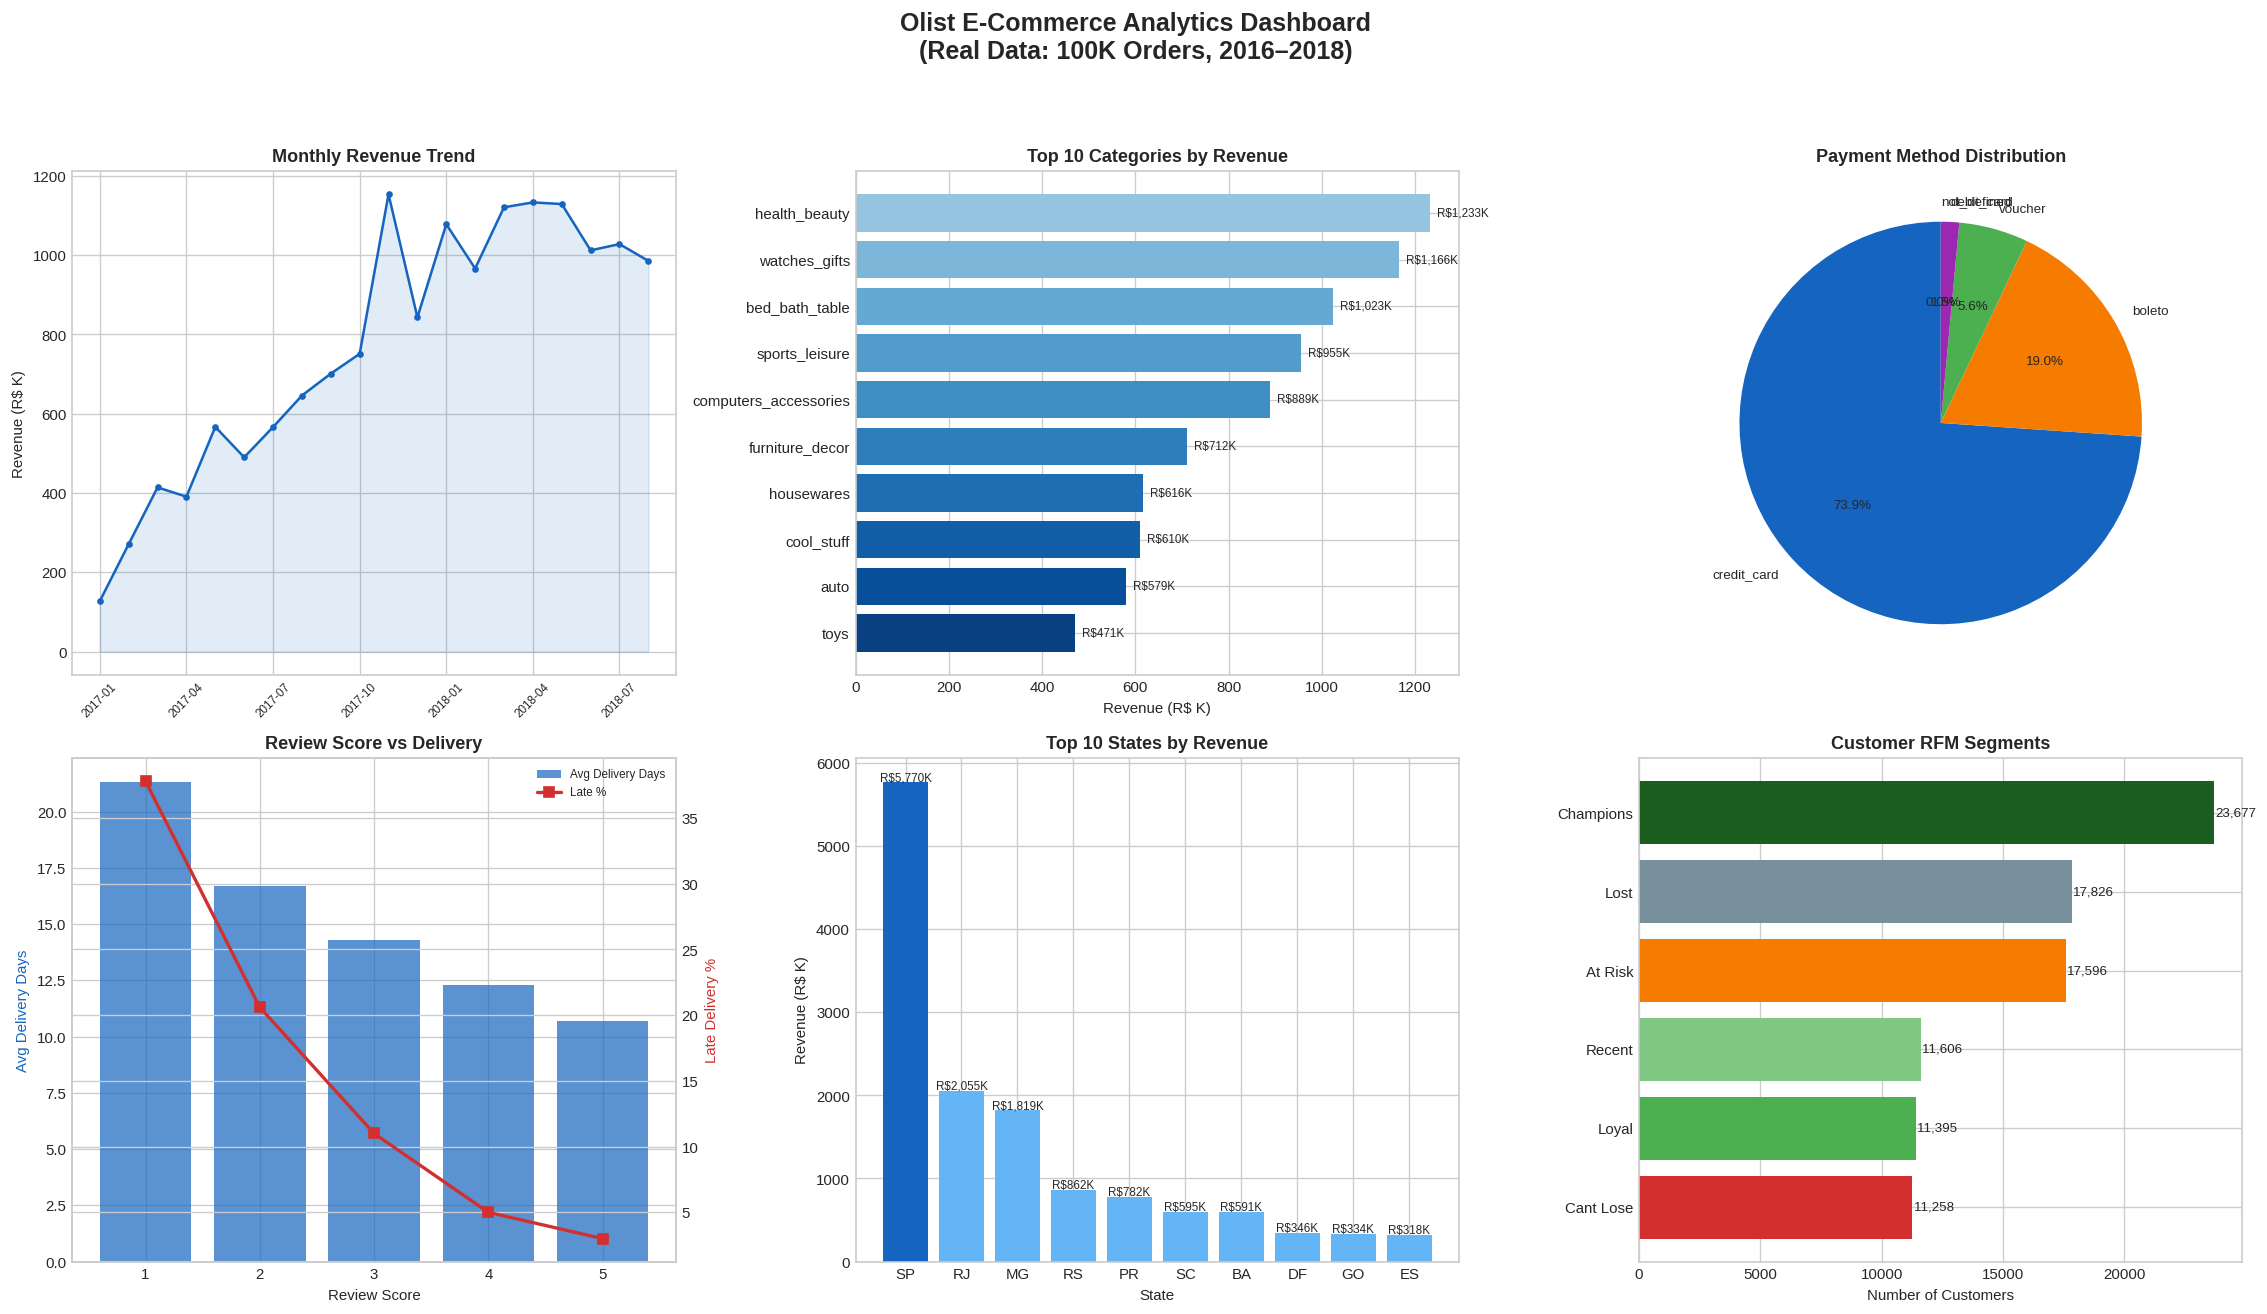


 Dashboard saved to dashboard.png


In [18]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 9

fig, axes = plt.subplots(2, 3, figsize=(19, 11))
fig.suptitle("Olist E-Commerce Analytics Dashboard\n(Real Data: 100K Orders, 2016–2018)",
             fontsize=15, fontweight='bold', y=0.99)

# ── Chart 1: Monthly Revenue Trend ──
ax = axes[0, 0]
df = sql("""
    SELECT STRFTIME('%Y-%m', o.order_purchase_timestamp) AS month,
           ROUND(SUM(oi.price + oi.freight_value) / 1000, 1) AS revenue_k
    FROM orders o JOIN order_items oi ON o.order_id = oi.order_id
    WHERE o.order_status = 'delivered' AND o.order_purchase_timestamp BETWEEN '2017-01-01' AND '2018-08-31'
    GROUP BY month ORDER BY month
""")
ax.plot(range(len(df)), df['revenue_k'], color='#1565C0', marker='o', markersize=3, linewidth=1.5)
ax.fill_between(range(len(df)), df['revenue_k'], alpha=0.12, color='#1565C0')
ax.set_title("Monthly Revenue Trend", fontweight='bold')
ax.set_ylabel("Revenue (R$ K)")
ticks = range(0, len(df), 3)
ax.set_xticks(ticks)
ax.set_xticklabels([df['month'].iloc[i] for i in ticks], rotation=45, fontsize=7)

# ── Chart 2: Top 10 Categories ──
ax = axes[0, 1]
df = sql("""
    SELECT COALESCE(ct.product_category_name_english, 'Other') AS category,
           ROUND(SUM(oi.price)/1000, 1) AS revenue_k
    FROM order_items oi
    JOIN products p ON oi.product_id = p.product_id
    LEFT JOIN category_translation ct ON p.product_category_name = ct.product_category_name
    JOIN orders o ON oi.order_id = o.order_id
    WHERE o.order_status = 'delivered'
    GROUP BY category ORDER BY revenue_k DESC LIMIT 10
""")
bars = ax.barh(df['category'], df['revenue_k'], color=plt.cm.Blues([0.4+0.06*i for i in range(len(df))]))
ax.set_xlabel("Revenue (R$ K)")
ax.set_title("Top 10 Categories by Revenue", fontweight='bold')
ax.invert_yaxis()
for bar, val in zip(bars, df['revenue_k']):
    ax.text(bar.get_width()+15, bar.get_y()+bar.get_height()/2, f'R${val:,.0f}K', va='center', fontsize=7)

# ── Chart 3: Payment Distribution ──
ax = axes[0, 2]
df = sql("SELECT payment_type, COUNT(*) AS cnt FROM order_payments GROUP BY payment_type ORDER BY cnt DESC")
ax.pie(df['cnt'], labels=df['payment_type'], autopct='%1.1f%%',
       colors=['#1565C0','#F57C00','#4CAF50','#9C27B0','#78909C'][:len(df)], startangle=90, textprops={'fontsize':8})
ax.set_title("Payment Method Distribution", fontweight='bold')

# ── Chart 4: Review vs Delivery ──
ax = axes[1, 0]
df = sql("""
    SELECT r.review_score,
           ROUND(AVG(JULIANDAY(o.order_delivered_customer_date)-JULIANDAY(o.order_purchase_timestamp)),1) AS avg_days,
           ROUND(100.0*SUM(CASE WHEN o.order_delivered_customer_date>o.order_estimated_delivery_date THEN 1 ELSE 0 END)/COUNT(*),1) AS late_pct
    FROM order_reviews r JOIN orders o ON r.order_id = o.order_id
    WHERE o.order_status='delivered' AND o.order_delivered_customer_date IS NOT NULL
    GROUP BY r.review_score ORDER BY r.review_score
""")
ax.bar(df['review_score'], df['avg_days'], color='#1565C0', alpha=0.7, label='Avg Delivery Days')
ax.set_xlabel("Review Score"); ax.set_ylabel("Avg Delivery Days", color='#1565C0')
ax.set_title("Review Score vs Delivery", fontweight='bold')
ax2 = ax.twinx()
ax2.plot(df['review_score'], df['late_pct'], color='#D32F2F', marker='s', linewidth=2, label='Late %')
ax2.set_ylabel("Late Delivery %", color='#D32F2F')
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1+lines2, labels1+labels2, fontsize=7, loc='upper right')

# ── Chart 5: Top States ──
ax = axes[1, 1]
df = sql("""
    SELECT c.customer_state, ROUND(SUM(oi.price+oi.freight_value)/1000,1) AS revenue_k
    FROM customers c JOIN orders o ON c.customer_id=o.customer_id
    JOIN order_items oi ON o.order_id=oi.order_id
    WHERE o.order_status='delivered'
    GROUP BY c.customer_state ORDER BY revenue_k DESC LIMIT 10
""")
bars = ax.bar(df['customer_state'], df['revenue_k'], color=['#1565C0']+['#64B5F6']*(len(df)-1))
ax.set_xlabel("State"); ax.set_ylabel("Revenue (R$ K)")
ax.set_title("Top 10 States by Revenue", fontweight='bold')
for bar, val in zip(bars, df['revenue_k']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+20, f'R${val:,.0f}K', ha='center', fontsize=7)

# ── Chart 6: RFM Segments ──
ax = axes[1, 2]
df = sql("""
    WITH rfm AS (
        SELECT c.customer_unique_id,
               CAST(JULIANDAY('2018-09-01')-JULIANDAY(MAX(o.order_purchase_timestamp)) AS INTEGER) AS recency,
               COUNT(DISTINCT o.order_id) AS frequency,
               ROUND(SUM(oi.price+oi.freight_value),2) AS monetary
        FROM customers c JOIN orders o ON c.customer_id=o.customer_id
        JOIN order_items oi ON o.order_id=oi.order_id WHERE o.order_status='delivered'
        GROUP BY c.customer_unique_id
    ), scored AS (
        SELECT *, NTILE(4) OVER (ORDER BY recency DESC) AS r,
               NTILE(4) OVER (ORDER BY frequency ASC) AS f,
               NTILE(4) OVER (ORDER BY monetary ASC) AS m FROM rfm
    )
    SELECT CASE WHEN r>=3 AND f>=3 AND m>=3 THEN 'Champions'
                WHEN r>=3 AND f>=2 THEN 'Loyal'
                WHEN r>=3 THEN 'Recent'
                WHEN r>=2 AND f>=2 THEN 'At Risk'
                WHEN f>=3 THEN 'Cant Lose'
                ELSE 'Lost' END AS segment, COUNT(*) AS cnt
    FROM scored GROUP BY segment ORDER BY cnt DESC
""")
seg_colors = {'Champions':'#1B5E20','Loyal':'#4CAF50','Recent':'#81C784',
              'At Risk':'#F57C00','Cant Lose':'#D32F2F','Lost':'#78909C'}
bars = ax.barh(df['segment'], df['cnt'], color=[seg_colors.get(s,'#999') for s in df['segment']])
ax.set_xlabel("Number of Customers"); ax.set_title("Customer RFM Segments", fontweight='bold')
ax.invert_yaxis()
for bar, val in zip(bars, df['cnt']):
    ax.text(bar.get_width()+50, bar.get_y()+bar.get_height()/2, f'{val:,}', va='center', fontsize=8)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("dashboard.png", bbox_inches='tight', facecolor='white')
plt.show()
print("\n Dashboard saved to dashboard.png")